In [ ]:
#Import Libraries

import os
import time
import copy
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

In [ ]:
#Set Up Device

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [ ]:
#Prepare the Dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("Test samples:", len(test_dataset))

100%|██████████| 170M/170M [43:10<00:00, 65.8kB/s]   


Test samples: 10000


In [ ]:
#Load the Trained ResNet18

from pathlib import Path

model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    10
)

model_path = Path(
    "/Users/mukul/ai-ml-internship-portfolio/phase 3/results/day13_14_resnet18_best.pth"
)

print("Model file:", model_path)
print("File exists:", model_path.exists())

checkpoint = torch.load(
    model_path,
    map_location=device,
    weights_only=False
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("ResNet18 loaded successfully.")

Model file: /Users/mukul/ai-ml-internship-portfolio/phase 3/results/day13_14_resnet18_best.pth
File exists: True
ResNet18 loaded successfully.


In [ ]:
#Evaluate the Original Model

def evaluate_model(model, loader):
    model.eval()

    correct = 0
    total = 0

    start_time = time.perf_counter()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    inference_time = time.perf_counter() - start_time
    accuracy = correct / total

    return accuracy, inference_time


original_accuracy, original_time = evaluate_model(
    model,
    test_loader
)

print("Original model accuracy:", round(original_accuracy, 4))
print("Original inference time:", round(original_time, 3), "seconds")

Original model accuracy: 0.1778
Original inference time: 4.269 seconds


In [ ]:
#Check Model Size

def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


def model_size_mb(model):
    total_bytes = 0

    for parameter in model.parameters():
        total_bytes += parameter.nelement() * parameter.element_size()

    for buffer in model.buffers():
        total_bytes += buffer.nelement() * buffer.element_size()

    return total_bytes / (1024 ** 2)


original_parameters = count_parameters(model)
original_size = model_size_mb(model)

print("Parameters:", f"{original_parameters:,}")
print("Model size:", round(original_size, 2), "MB")

Parameters: 11,181,642
Model size: 42.69 MB


In [ ]:
#Create a Pruned Model

pruned_model = copy.deepcopy(model)

parameters_to_prune = []

for module in pruned_model.modules():

    if isinstance(module, nn.Conv2d):
        parameters_to_prune.append(
            (module, "weight")
        )

    elif isinstance(module, nn.Linear):
        parameters_to_prune.append(
            (module, "weight")
        )

print("Layers selected for pruning:", len(parameters_to_prune))

Layers selected for pruning: 21


In [ ]:
# Apply 20% Pruning

for module, parameter_name in parameters_to_prune:

    prune.l1_unstructured(
        module,
        name=parameter_name,
        amount=0.20
    )

print("20% pruning applied.")

20% pruning applied.


In [ ]:
#Check Sparsity

def calculate_sparsity(model):

    total = 0
    zeros = 0

    for module in model.modules():

        if isinstance(module, (nn.Conv2d, nn.Linear)):

            weight = module.weight.detach()

            total += weight.numel()
            zeros += torch.sum(weight == 0).item()

    return zeros / total


sparsity = calculate_sparsity(pruned_model)

print(
    "Overall sparsity:",
    round(sparsity * 100, 2),
    "%"
)

Overall sparsity: 20.0 %


In [ ]:
# Evaluate the Pruned Model

pruned_model = pruned_model.to(device)

pruned_accuracy, pruned_time = evaluate_model(
    pruned_model,
    test_loader
)

print("Pruned model accuracy:", round(pruned_accuracy, 4))
print("Pruned inference time:", round(pruned_time, 3), "seconds")

Pruned model accuracy: 0.1808
Pruned inference time: 1.768 seconds


In [ ]:
# Make Pruning Permanent

for module, parameter_name in parameters_to_prune:

    prune.remove(
        module,
        parameter_name
    )

print("Pruning masks removed and pruning made permanent.")

Pruning masks removed and pruning made permanent.


In [ ]:
# Check Pruned Model Size

pruned_parameters = count_parameters(pruned_model)
pruned_size = model_size_mb(pruned_model)

print("Pruned parameters:", f"{pruned_parameters:,}")
print("Pruned model size:", round(pruned_size, 2), "MB")

Pruned parameters: 11,181,642
Pruned model size: 42.69 MB


In [ ]:
# Compare Both Models

comparison = pd.DataFrame({

    "Model": [
        "Original ResNet18",
        "Pruned ResNet18"
    ],

    "Accuracy": [
        original_accuracy,
        pruned_accuracy
    ],

    "Inference Time (s)": [
        original_time,
        pruned_time
    ],

    "Parameters": [
        original_parameters,
        pruned_parameters
    ],

    "Model Size (MB)": [
        original_size,
        pruned_size
    ],

    "Sparsity": [
        0,
        sparsity
    ]
})

comparison

,Model,Accuracy,Inference Time (s),Parameters,Model Size (MB),Sparsity
0,Original ResNet18,0.1778,4.269032,11181642,42.691353,0.0
1,Pruned ResNet18,0.1808,1.767509,11181642,42.691353,0.2


In [ ]:
# Calculate the Trade-offs

accuracy_change = pruned_accuracy - original_accuracy

size_reduction = (
    (original_size - pruned_size)
    / original_size
) * 100

time_change = (
    (pruned_time - original_time)
    / original_time
) * 100

print("Accuracy change:", round(accuracy_change, 4))
print("Size reduction:", round(size_reduction, 2), "%")
print("Inference time change:", round(time_change, 2), "%")

Accuracy change: 0.003
Size reduction: 0.0 %
Inference time change: -58.6 %


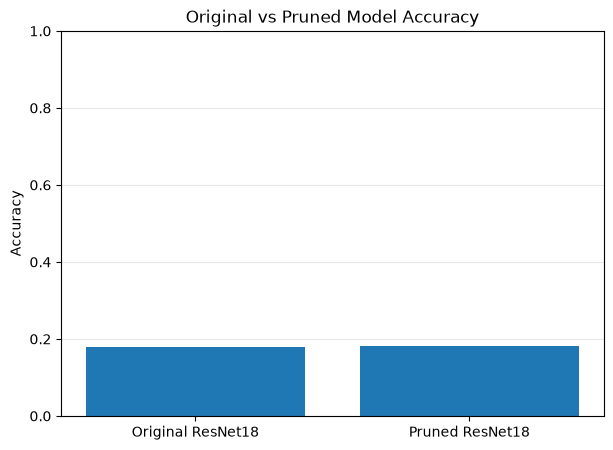

In [ ]:
# Plot Accuracy Comparison

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Original vs Pruned Model Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()

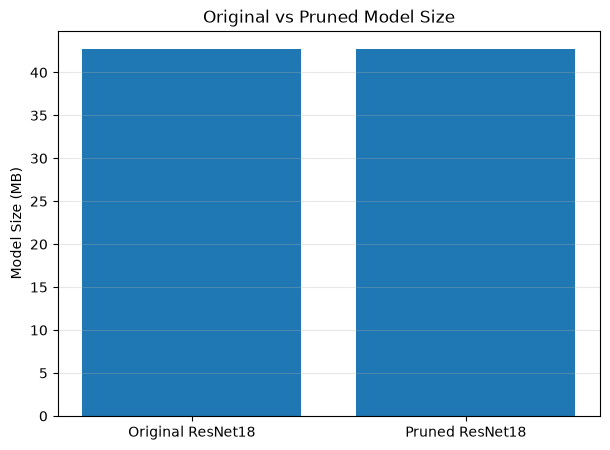

In [ ]:
# Plot Model Size

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Model Size (MB)"]
)

plt.ylabel("Model Size (MB)")
plt.title("Original vs Pruned Model Size")
plt.grid(axis="y", alpha=0.3)

plt.show()

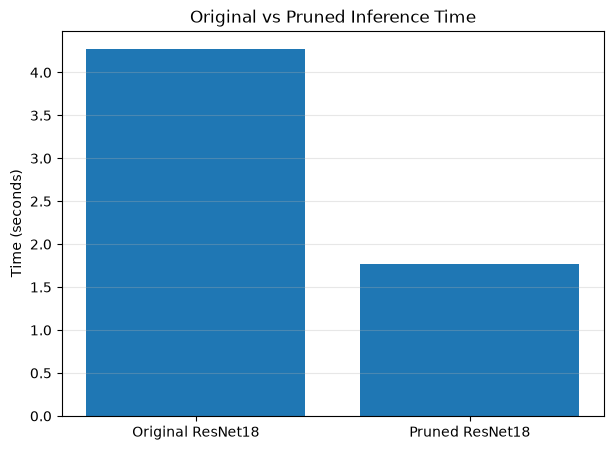

In [ ]:
# Plot Inference Time

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Inference Time (s)"]
)

plt.ylabel("Time (seconds)")
plt.title("Original vs Pruned Inference Time")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Save the Results

os.makedirs("results", exist_ok=True)

comparison.to_csv(
    "results/day15_efficiency_tradeoffs.csv",
    index=False
)

torch.save(
    pruned_model.state_dict(),
    "results/day15_pruned_resnet18.pth"
)

print("Results saved successfully.")

Results saved successfully.


In [ ]:
# Final Results

print("=" * 50)
print("DAY 15 RESULTS")
print("=" * 50)

print(
    f"Original accuracy : {original_accuracy:.4f}"
)

print(
    f"Pruned accuracy   : {pruned_accuracy:.4f}"
)

print(
    f"Accuracy change   : {accuracy_change:+.4f}"
)

print(
    f"Original size     : {original_size:.2f} MB"
)

print(
    f"Pruned size       : {pruned_size:.2f} MB"
)

print(
    f"Size reduction    : {size_reduction:.2f}%"
)

print(
    f"Original time     : {original_time:.3f} sec"
)

print(
    f"Pruned time       : {pruned_time:.3f} sec"
)

print(
    f"Sparsity          : {sparsity:.2%}"
)

print("\nDay 15 efficiency experiment completed.")

DAY 15 RESULTS
Original accuracy : 0.1778
Pruned accuracy   : 0.1808
Accuracy change   : +0.0030
Original size     : 42.69 MB
Pruned size       : 42.69 MB
Size reduction    : 0.00%
Original time     : 4.269 sec
Pruned time       : 1.768 sec
Sparsity          : 20.00%

Day 15 efficiency experiment completed.
